## 01 Import Data

### 01-1 Setup Config

In [2]:
from dotenv import load_dotenv
from utils import init_mlflow
import os
import json
load_dotenv()
POSTGRES_URI = os.getenv('POSTGRES_URI')
os.environ["GIT_PYTHON_REFRESH"] = "quiet"

# Set the stock code you want to analyze
STOCK_CODE = 2330

map_dict_path = '/app/data/column_mapping.json'
init_mlflow()
with open(map_dict_path, 'r', encoding='utf-8') as f:
    map_dict = json.load(f)
# '6770', '2337', '2344', '2303', '2408', '2515', '5521', '2542', '1316', '2442', '2485', '6285', '2455', '2412', '4977', '2367', '2313', '3037', '4958', '2327'

In [3]:
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, r2_score
from collections import defaultdict
import math
import time
import mlflow

%matplotlib inline

START_DATE = "2020-01-01"
END_DATE = time.strftime("%Y-%m-%d")

stock_dict_path = '/app/data/top5_stocks_by_category.json'
with open(stock_dict_path, 'r', encoding='utf-8') as f:
    stock_dict = json.load(f)

sns.set(style='whitegrid', palette='muted', font_scale=1.2)
Colour_Palette = ['#01BEFE', '#FF7D00', '#FFDD00', '#FF006D', '#ADFF02', '#8F00FF']
sns.set_palette(sns.color_palette(Colour_Palette))
tqdm.pandas()
mlflow.set_experiment("LSTM_Test")
mlflow.config.enable_system_metrics_logging()
mlflow.config.set_system_metrics_sampling_interval(1)

### 01-2 Load Data

In [4]:
[int(x) for x in stock_dict['半導體業']]

[2330, 2408, 2344, 6770, 2337]

In [5]:
def get_stock_data(stock_code, start_date: str, end_date: str, return_all=False):
    # Fetch data from PostgreSQL database
    table_name = f'daily_info_{stock_code}'
    query = f"""
    SELECT *
    FROM {table_name}
    WHERE stock_code_id = '{stock_code}'
      AND date BETWEEN '{start_date}' AND '{end_date}'
    ORDER BY date ASC;
    """
    df = pd.read_sql(query, POSTGRES_URI)

    # Rename columns using the mapping dictionary
    df.rename(columns=map_dict, inplace=True)
    return df

def get_stock_data_by_category(category, start_date: str, end_date: str):
    """
    category: 'ETF', '建材營造', '電子零組件業', '半導體業', '通信網路業'
    """
    stock_codes = stock_dict.get(category, [])
    stock_codes = [int(code) for code in stock_codes]
    all_data = []
    for code in stock_codes:
        try:
            df = get_stock_data(code, start_date, end_date)
            all_data.append(df)
        except Exception as e:
            print(f"Error fetching data for stock code {code}: {e}")
    final_df = pd.concat(all_data, ignore_index=True)
    # final_df = final_df.sort_values(by=['date', 'stock_code_id']).reset_index(drop=True)
    return final_df

df = get_stock_data_by_category("半導體業", START_DATE, END_DATE)
df.head()

Error fetching data for stock code 6770: (psycopg.errors.UndefinedTable) relation "daily_info_6770" does not exist
LINE 3:     FROM daily_info_6770
                 ^
[SQL: 
    SELECT *
    FROM daily_info_6770
    WHERE stock_code_id = '6770'
      AND date BETWEEN '2020-01-01' AND '2026-04-21'
    ORDER BY date ASC;
    ]
(Background on this error at: https://sqlalche.me/e/20/f405)


,date,capacity,turnover,high,low,close,change,transaction_volume,stock_code_id,open
0,2020-01-02 01:00:00,33282120.0,1.122417e+10,339.0,332.5,339.0,8.0,17160,2330,332.5
1,2020-01-03 01:00:00,42023268.0,1.429565e+10,345.0,335.5,339.5,0.5,20545,2330,344.0
2,2020-01-06 01:00:00,45677057.0,1.521053e+10,334.5,332.0,332.0,-7.5,22944,2330,333.0
3,2020-01-07 01:00:00,51746181.0,1.705328e+10,333.0,326.5,329.5,-2.5,22362,2330,332.5
4,2020-01-08 01:00:00,37913748.0,1.248441e+10,333.0,325.0,329.5,0.0,18228,2330,325.0


In [6]:
def check_missing_values(df: pd.DataFrame)-> pd.DataFrame:
    # Fill null values in 'change' using the values from 'change_new' (today's close - yesterday's close)
    # df['change_new'] = df['close']-df['close'].shift(1)
    # df['change'] = df['change'].fillna(df['change_new'])
    # df = df.drop(columns=['change_new'])
    print(df.isnull().sum())
    return df

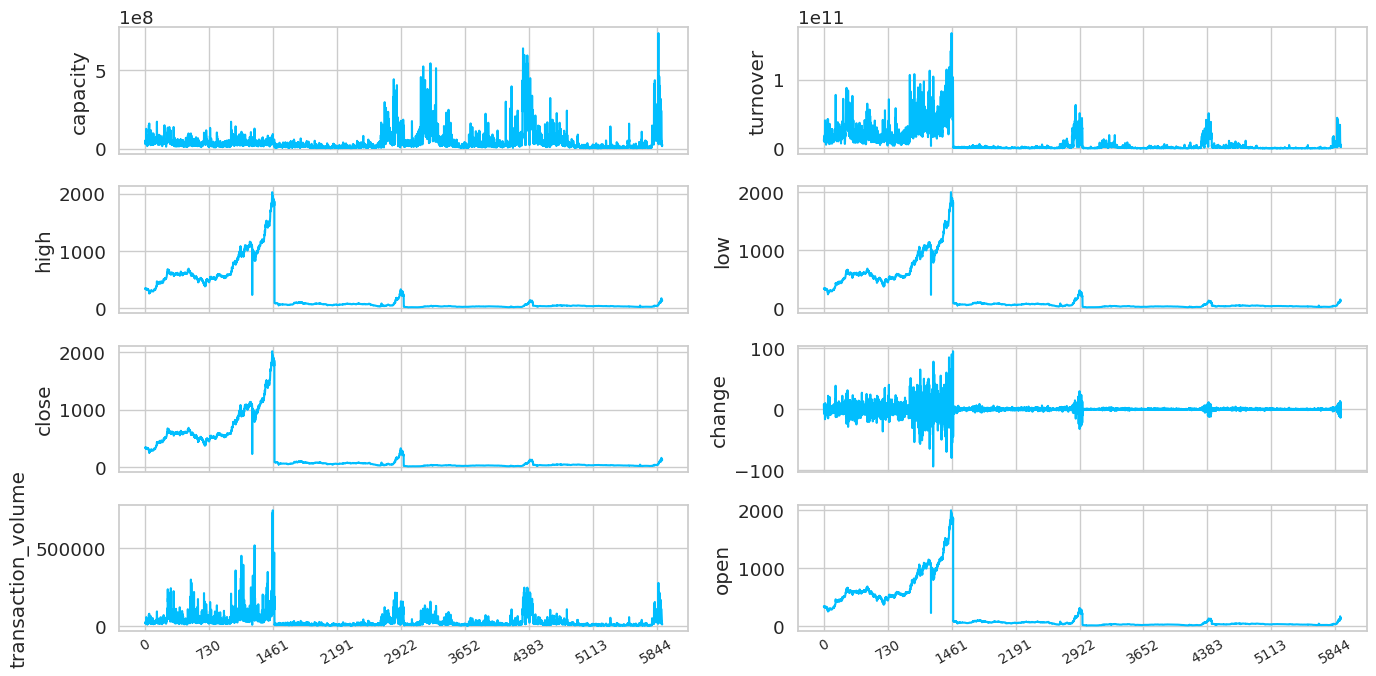

In [7]:
def data_plot(df):
    # Plot line charts
    df_plot = df.drop(columns=['stock_code_id', 'date'])

    ncols = 2
    nrows = int(round(df_plot.shape[1] / ncols, 0))

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, figsize=(14, 7))
    for i, ax in enumerate(fig.axes):
        sns.lineplot(data=df_plot.iloc[:, i], ax=ax)
        ax.tick_params(axis="x", rotation=30, labelsize=10, length=0)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.tight_layout()
    plt.show()

data_plot(df)

### 01-3 Feature Engineering

In [9]:
# Multi-stock feature engineering (4 stocks in the same industry)
PREDICT_COL = 'close'

# 1) Pick 4 stock codes and align by date
selected_stocks = sorted(df['stock_code_id'].unique())[:4]
print(f"Selected stock codes: {selected_stocks}")

# Keep only required rows/columns and normalize date granularity
df_sub = df[df['stock_code_id'].isin(selected_stocks)].copy()
df_sub['date'] = pd.to_datetime(df_sub['date']).dt.normalize()

# If same stock has duplicate rows on the same date, keep one value by aggregation
dup_cnt = int(df_sub.duplicated(subset=['date', 'stock_code_id']).sum())
if dup_cnt > 0:
    print(f"Found {dup_cnt} duplicate (date, stock_code_id) rows. Aggregating by mean {PREDICT_COL}.")

close_daily = (
    df_sub.groupby(['date', 'stock_code_id'], as_index=False)[PREDICT_COL]
    .mean()
    .sort_values(['date', 'stock_code_id'])
)

# Use pivot_table to safely reshape even if duplicates exist
close_wide = (
    close_daily.pivot_table(
        index='date',
        columns='stock_code_id',
        values=PREDICT_COL,
        aggfunc='mean',
    )
    .sort_index()
    .ffill()
    .bfill()
)
close_wide.columns = [f"close_{int(code)}" for code in close_wide.columns]

# 2) Build cross-stock features
ret_wide = close_wide.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
ret_wide.columns = [f"ret_{col.split('_')[1]}" for col in close_wide.columns]

market_mean_close = close_wide.mean(axis=1).to_frame('market_mean_close')
market_mean_ret = ret_wide.mean(axis=1).to_frame('market_mean_ret')

rel_close = close_wide.sub(close_wide.mean(axis=1), axis=0)
rel_close.columns = [f"rel_{col}" for col in close_wide.columns]

feature_df = pd.concat(
    [close_wide, ret_wide, market_mean_close, market_mean_ret, rel_close],
    axis=1,
).dropna()

target_cols = close_wide.columns.tolist()
feature_cols = feature_df.columns.tolist()

# 3) walk-forward split
X_all = feature_df[feature_cols].values
y_all = feature_df[target_cols].values
dataset_all = feature_df.index


print(f"Total samples: {len(X_all)}")
print("Features:", X_all.shape[1], "Target:", y_all.shape[1])

Selected stock codes: ['2330', '2337', '2344', '2408']
Found 5 duplicate (date, stock_code_id) rows. Aggregating by mean close.
Total samples: 1476
Features: 14 Target: 4


In [10]:
def generate_walkforward_splits(n_totals, initial_train_size, test_size, step_size):
    splits = []
    train_end = initial_train_size

    while train_end + test_size <= n_totals:
        train_idx = np.arange(0, train_end)
        test_idx = np.arange(train_end, train_end + test_size)
        splits.append((train_idx, test_idx))
        train_end += step_size

    return splits

# Example
initial_train_size = int(len(X_all) * 0.5)
test_size = 21
step_size = 21

splits = generate_walkforward_splits(len(X_all), initial_train_size, test_size, step_size)
print(f"Num folds: {len(splits)}")
print("First fold train/test size:", len(splits[0][0]), len(splits[0][1]))

Num folds: 35
First fold train/test size: 738 21


In [11]:
SEQUENCE_LENGTH = 7  # Number of time steps to look back

def create_sequences(X_array, y_array, seq_len):
    X_out, y_out = [], []
    for i in range(len(X_array) - seq_len):
        X_out.append(X_array[i:i+seq_len])
        y_out.append(y_array[i+seq_len])
    return np.array(X_out), np.array(y_out)

def build_fold_tensors(X_all, y_all, train_idx, test_idx, seq_len):
    # Split raw
    X_train_raw, y_train_raw = X_all[train_idx], y_all[train_idx]
    X_test_raw, y_test_raw = X_all[test_idx], y_all[test_idx]

    # Fit Scaler on train only
    x_scaler = MinMaxScaler((0, 1))
    y_scaler = MinMaxScaler((0, 1))
    X_train_scaled = x_scaler.fit_transform(X_train_raw)
    y_train_scaled = y_scaler.fit_transform(y_train_raw)
    X_test_scaled = x_scaler.transform(X_test_raw)
    y_test_scaled = y_scaler.transform(y_test_raw)

    # Create sequences for train
    X_train_np, y_train_np = create_sequences(X_train_scaled, y_train_scaled, seq_len)
    
    # Create sequences for test
    X_test_input = np.vstack([X_train_scaled[-seq_len:], X_test_scaled])
    y_test_input = np.vstack([y_train_scaled[-seq_len:], y_test_scaled])
    X_test_np, y_test_np = create_sequences(X_test_input, y_test_input, seq_len)

    # Convert to tensors
    X_train = torch.tensor(X_train_np, dtype=torch.float32)
    y_train = torch.tensor(y_train_np, dtype=torch.float32)
    X_test = torch.tensor(X_test_np, dtype=torch.float32)
    y_test = torch.tensor(y_test_np, dtype=torch.float32)

    return X_train, y_train, X_test, y_test, y_scaler

## 02 Model Training

### 02-1 Create Sequences and Labels for training and testing

In [12]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :])  # Use the output of the last time step
        return out
    
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")  

Using device: cuda


In [13]:
def train_one_fold(X_train, y_train, X_test, y_test, y_scaler, params, device, epochs=50, batch_size=32):
    model = LSTMModel(
        params['input_size'],
        params['hidden_size'],
        params['num_layers'],
        params['output_size'],
        params['dropout']
    ).to(device)

    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    # train
    model.train()
    for _ in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

    # eval
    model.eval()
    preds_scaled, trues_scaled = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds_scaled.append(pred)
            trues_scaled.append(yb.numpy())

    preds_scaled = np.concatenate(preds_scaled, axis=0)
    trues_scaled = np.concatenate(trues_scaled, axis=0)

    pred_inv = y_scaler.inverse_transform(preds_scaled)
    true_inv = y_scaler.inverse_transform(trues_scaled)

    rmse_by_stock = np.sqrt(np.mean((pred_inv - true_inv) ** 2, axis=0))
    r2_by_stock = [r2_score(true_inv[:, i], pred_inv[:, i]) for i in range(true_inv.shape[1])]

    return {
        "rmse_by_stock": rmse_by_stock,
        "r2_by_stock": r2_by_stock,
        "avg_rmse": float(np.mean(rmse_by_stock)),
        "avg_r2": float(np.mean(r2_by_stock)),
    }

In [14]:
params = {
    "input_size": X_all.shape[1],
    "hidden_size": 32,
    "num_layers": 3,
    "output_size": y_all.shape[1],
    "dropout": 0.3
}

def train_one_fold_with_model(X_train, y_train, X_test, y_test, y_scaler, params, device, epochs=50, batch_size=32):
    model = LSTMModel(
        params['input_size'],
        params['hidden_size'],
        params['num_layers'],
        params['output_size'],
        params['dropout']
    ).to(device)

    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    model.train()
    for _ in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    preds_scaled, trues_scaled = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds_scaled.append(pred)
            trues_scaled.append(yb.numpy())

    preds_scaled = np.concatenate(preds_scaled, axis=0)
    trues_scaled = np.concatenate(trues_scaled, axis=0)

    pred_inv = y_scaler.inverse_transform(preds_scaled)
    true_inv = y_scaler.inverse_transform(trues_scaled)

    rmse_by_stock = np.sqrt(np.mean((pred_inv - true_inv) ** 2, axis=0))
    r2_by_stock = [r2_score(true_inv[:, i], pred_inv[:, i]) for i in range(true_inv.shape[1])]

    metrics = {
        "rmse_by_stock": rmse_by_stock,
        "r2_by_stock": r2_by_stock,
        "avg_rmse": float(np.mean(rmse_by_stock)),
        "avg_r2": float(np.mean(r2_by_stock)),
    }

    return model, metrics

all_fold_metrics = []
best_model_state = None
best_metrics = None
best_fold_no = None
best_rmse = float("inf")
num_epochs = 50
batch_size = 32

with mlflow.start_run(run_name=f"walkforward_{time.strftime('%Y%m%d_%H%M%S')}"):
    mlflow.log_params({
        "input_size": params["input_size"],
        "hidden_size": params["hidden_size"],
        "num_layers": params["num_layers"],
        "output_size": params["output_size"],
        "dropout": params["dropout"],
        "sequence_length": SEQUENCE_LENGTH,
        "num_folds": len(splits),
        "epochs": num_epochs,
        "batch_size": batch_size,
    })

    for fold_no, (train_idx, test_idx) in enumerate(splits, start=1):
        X_train, y_train, X_test, y_test, y_scaler = build_fold_tensors(
            X_all, y_all, train_idx, test_idx, SEQUENCE_LENGTH
        )

        if len(X_train) == 0 or len(X_test) == 0:
            continue

        model_fold, metrics = train_one_fold_with_model(
            X_train, y_train, X_test, y_test, y_scaler,
            params=params, device=device, epochs=num_epochs, batch_size=batch_size
        )

        all_fold_metrics.append(metrics)
        mlflow.log_metric("fold_avg_rmse", metrics["avg_rmse"], step=fold_no)
        mlflow.log_metric("fold_avg_r2", metrics["avg_r2"], step=fold_no)

        for i in range(len(metrics["rmse_by_stock"])):
            mlflow.log_metric(f"fold_rmse_stock_{i}", float(metrics["rmse_by_stock"][i]), step=fold_no)
            mlflow.log_metric(f"fold_r2_stock_{i}", float(metrics["r2_by_stock"][i]), step=fold_no)

        if metrics["avg_rmse"] < best_rmse:
            best_rmse = metrics["avg_rmse"]
            best_fold_no = fold_no
            best_metrics = metrics
            best_model_state = {k: v.detach().cpu().clone() for k, v in model_fold.state_dict().items()}

        print(f"Fold {fold_no}: avg RMSE={metrics['avg_rmse']:.4f}, avg R2={metrics['avg_r2']:.4f}")

    if best_model_state is None:
        raise ValueError("No valid fold for training. Please check split settings.")

    overall_avg_rmse = float(np.mean([m["avg_rmse"] for m in all_fold_metrics]))
    overall_avg_r2 = float(np.mean([m["avg_r2"] for m in all_fold_metrics]))

    mlflow.log_metric("overall_avg_rmse", overall_avg_rmse)
    mlflow.log_metric("overall_avg_r2", overall_avg_r2)
    mlflow.log_metric("best_avg_rmse", float(best_metrics["avg_rmse"]))
    mlflow.log_metric("best_avg_r2", float(best_metrics["avg_r2"]))
    mlflow.log_param("best_fold_no", int(best_fold_no))

    best_model = LSTMModel(
        params['input_size'],
        params['hidden_size'],
        params['num_layers'],
        params['output_size'],
        params['dropout']
    ).to(device)
    best_model.load_state_dict(best_model_state)
    best_model.eval()

    mlflow.pytorch.log_model(best_model, artifact_path="best_model")

print("Overall avg RMSE:", overall_avg_rmse)
print("Overall avg R2:", overall_avg_r2)
print(f"Best fold: {best_fold_no}, best avg RMSE={best_metrics['avg_rmse']:.4f}, best avg R2={best_metrics['avg_r2']:.4f}")

2026/04/21 08:37:59 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/21 08:37:59 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Fold 1: avg RMSE=4.7399, avg R2=-0.0580
Fold 2: avg RMSE=3.2504, avg R2=-0.5389
Fold 3: avg RMSE=6.8297, avg R2=-2.9916
Fold 4: avg RMSE=5.9696, avg R2=-20.7292
Fold 5: avg RMSE=6.2127, avg R2=-10.4725
Fold 6: avg RMSE=6.5682, avg R2=-12.8328
Fold 7: avg RMSE=4.9353, avg R2=-2.4924
Fold 8: avg RMSE=5.6744, avg R2=-0.4718
Fold 9: avg RMSE=4.2007, avg R2=-0.0387
Fold 10: avg RMSE=4.5360, avg R2=-2.3205
Fold 11: avg RMSE=2.2912, avg R2=0.4324
Fold 12: avg RMSE=7.9088, avg R2=0.0201
Fold 13: avg RMSE=29.0061, avg R2=-16.9441
Fold 14: avg RMSE=5.1685, avg R2=-0.1324
Fold 15: avg RMSE=7.1650, avg R2=-1.8029
Fold 16: avg RMSE=13.5134, avg R2=-0.2565
Fold 17: avg RMSE=25.3230, avg R2=-1.1696
Fold 18: avg RMSE=11.1604, avg R2=-10.6018
Fold 19: avg RMSE=14.5488, avg R2=-1.8853
Fold 20: avg RMSE=15.7113, avg R2=-6.4248
Fold 21: avg RMSE=14.2386, avg R2=-8.6502
Fold 22: avg RMSE=8.0650, avg R2=-2.9976
Fold 23: avg RMSE=7.1336, avg R2=0.3211
Fold 24: avg RMSE=54.8966, avg R2=-2.1294
Fold 25: avg RM

2026/04/21 08:44:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 35: avg RMSE=38.3373, avg R2=-2.1111


2026/04/21 08:44:14 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/04/21 08:44:14 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/21 08:44:21 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it

🏃 View run walkforward_20260421_083759 at: http://172.18.0.3:5000/#/experiments/2/runs/b014f37f5bbc42d28550a9f327250e97
🧪 View experiment at: http://172.18.0.3:5000/#/experiments/2
Overall avg RMSE: 17.55063580785479
Overall avg R2: -3.728794481924602
Best fold: 11, best avg RMSE=2.2912, best avg R2=0.4324


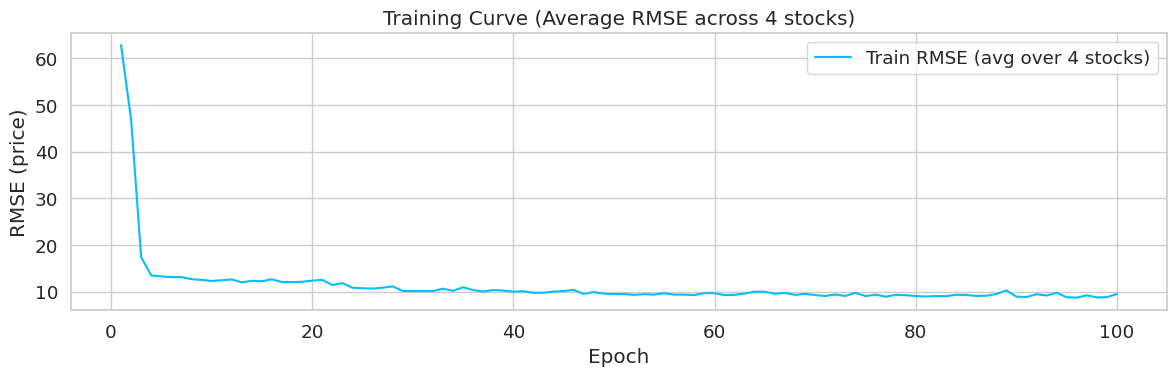

In [48]:
x = np.linspace(1, num_epochs, num_epochs)
plt.figure(figsize=(12, 4))
plt.plot(x, train_rmse_price_hist, label='Train RMSE (avg over 4 stocks)')
plt.xlabel('Epoch')
plt.ylabel('RMSE (price)')
plt.legend()
plt.title('Training Curve (Average RMSE across 4 stocks)')
plt.tight_layout()
plt.show()

## 03 Forecasting and evaluate

Last fold (Fold 35) - TEST metrics by stock:
Stock 2330 - RMSE: 55.7079, R²: -0.3788
Stock 2337 - RMSE: 27.3078, R²: -0.7106
Stock 2344 - RMSE: 14.8587, R²: -1.1992
Stock 2408 - RMSE: 55.4748, R²: -6.1558
Last fold TEST average RMSE (4 stocks): 38.3373
Last fold TEST average R² (4 stocks): -2.1111


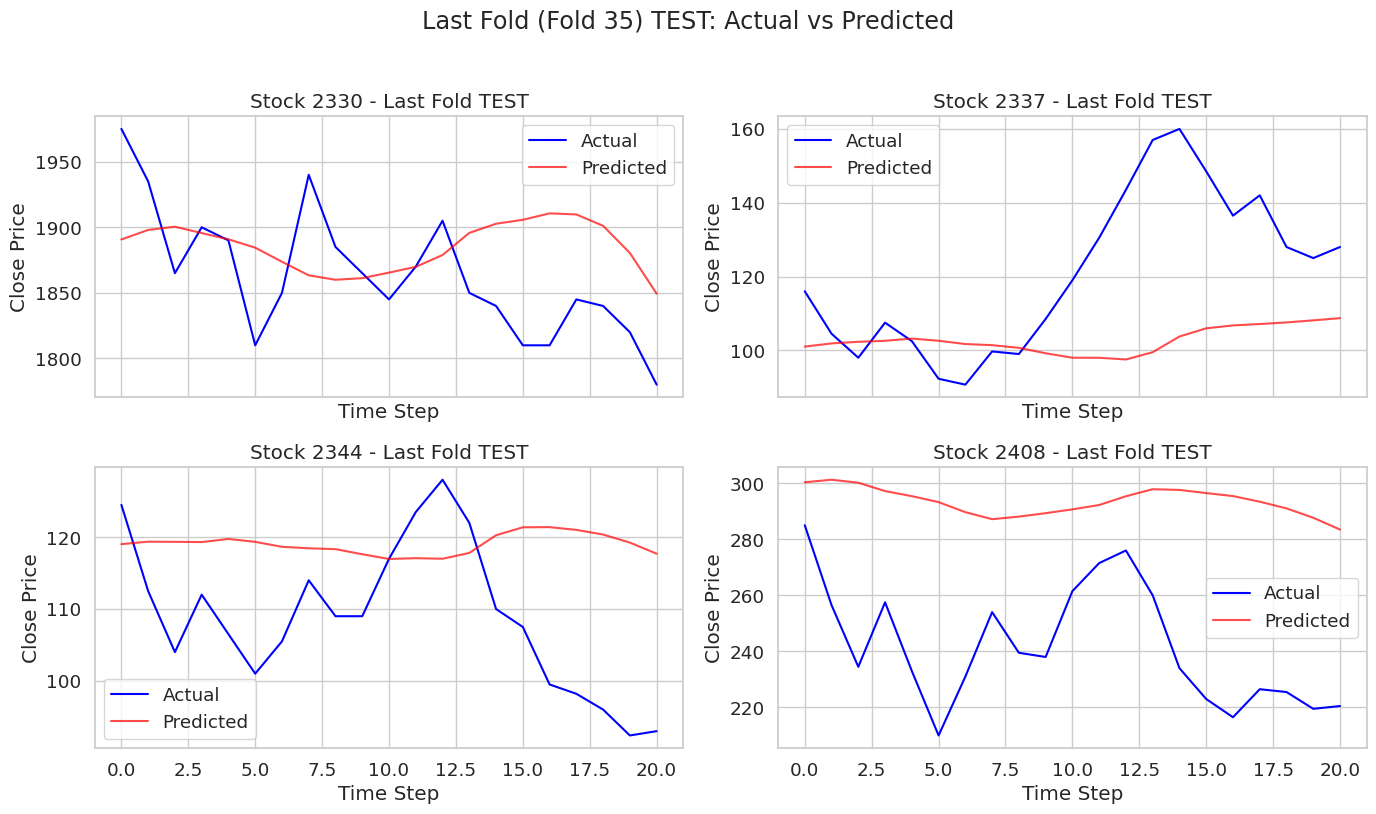

In [15]:
# Evaluate last fold on TEST set: per-stock RMSE and R²
if 'model_fold' not in globals():
    raise ValueError('Please run Cell 18 first to train walk-forward folds.')

last_fold_no = len(splits)
last_train_idx, last_test_idx = splits[-1]
X_train_last, y_train_last, X_test_last, y_test_last, y_scaler_last = build_fold_tensors(
    X_all, y_all, last_train_idx, last_test_idx, SEQUENCE_LENGTH
)

last_test_loader = DataLoader(
    TensorDataset(X_test_last, y_test_last),
    batch_size=32,
    shuffle=False,
    drop_last=False
)

model_fold.eval()
with torch.no_grad():
    test_predictions_scaled = []
    test_targets_scaled = []
    for batch_X_test, batch_y_test in last_test_loader:
        batch_X_test = batch_X_test.to(device)
        pred = model_fold(batch_X_test).cpu().numpy()
        test_predictions_scaled.append(pred)
        test_targets_scaled.append(batch_y_test.numpy())

test_predictions_scaled = np.concatenate(test_predictions_scaled, axis=0)
test_targets_scaled = np.concatenate(test_targets_scaled, axis=0)

# Inverse transform to original price scale
test_pred_inv = y_scaler_last.inverse_transform(test_predictions_scaled)
test_true_inv = y_scaler_last.inverse_transform(test_targets_scaled)

# Metrics by stock
rmse_by_stock = np.sqrt(np.mean((test_pred_inv - test_true_inv) ** 2, axis=0))
r2_by_stock = [
    r2_score(test_true_inv[:, i], test_pred_inv[:, i])
    for i in range(test_true_inv.shape[1])
]
stock_codes = [int(col.split('_')[1]) for col in target_cols]

print(f"Last fold (Fold {last_fold_no}) - TEST metrics by stock:")
for i, code in enumerate(stock_codes):
    print(f"Stock {code} - RMSE: {rmse_by_stock[i]:.4f}, R²: {r2_by_stock[i]:.4f}")

print(f"Last fold TEST average RMSE ({len(stock_codes)} stocks): {rmse_by_stock.mean():.4f}")
print(f"Last fold TEST average R² ({len(stock_codes)} stocks): {np.mean(r2_by_stock):.4f}")

# Plot actual vs predicted for each stock (last fold test)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, code in enumerate(stock_codes):
    axes[i].plot(test_true_inv[:, i], label='Actual', color='blue')
    axes[i].plot(test_pred_inv[:, i], label='Predicted', color='red', alpha=0.7)
    axes[i].set_title(f'Stock {code} - Last Fold TEST')
    axes[i].set_xlabel('Time Step')
    axes[i].set_ylabel('Close Price')
    axes[i].grid(True)
    axes[i].legend()

plt.suptitle(f'Last Fold (Fold {last_fold_no}) TEST: Actual vs Predicted', y=1.02)
plt.tight_layout()
plt.show()

Train metrics by stock:
Stock 2330 - RMSE: 33.4046, R²: 0.9770
Stock 2337 - RMSE: 1.1039, R²: 0.9751
Stock 2344 - RMSE: 0.8514, R²: 0.9814
Stock 2408 - RMSE: 2.6643, R²: 0.9667
Average RMSE (4 stocks): 9.5061
Average R² (4 stocks): 0.9750


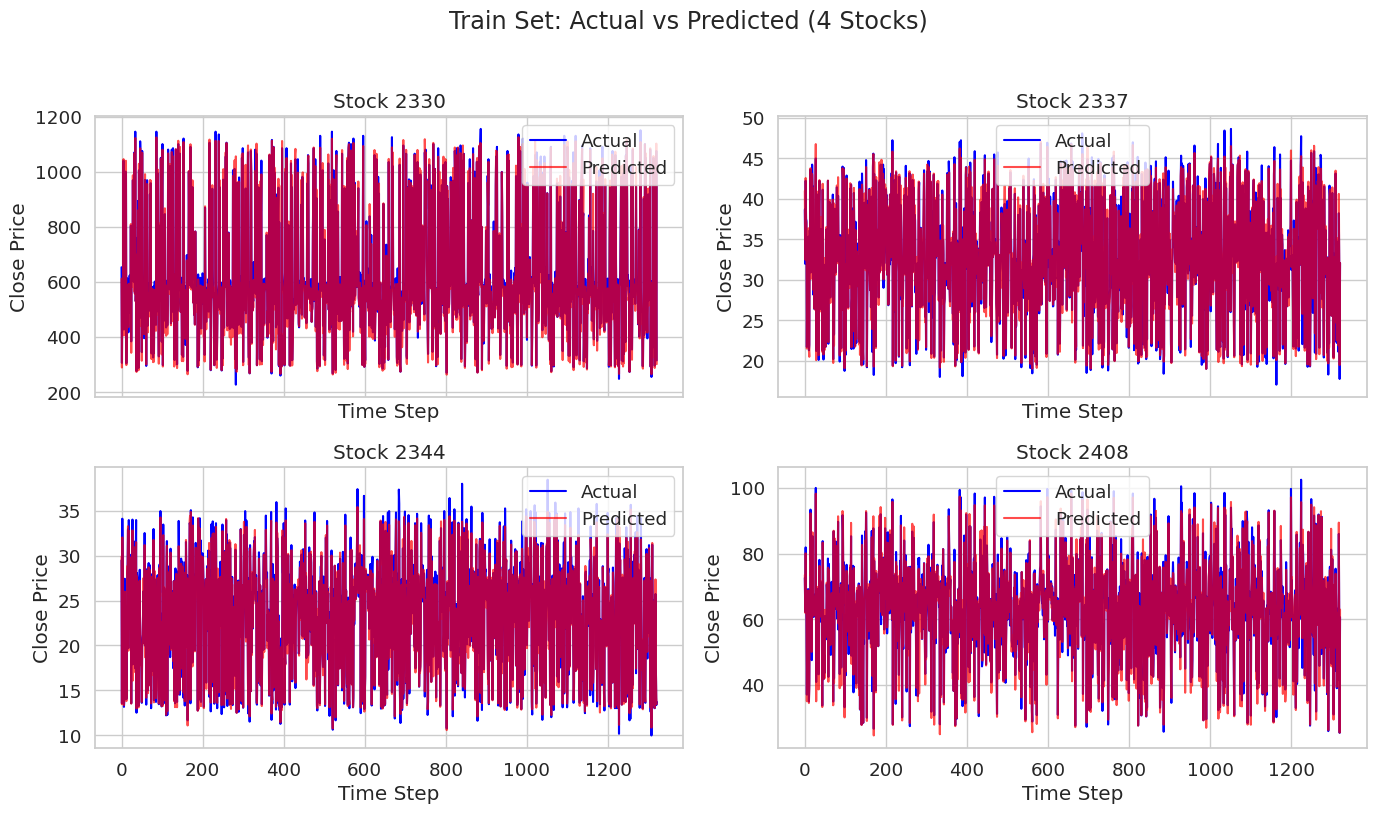

In [ ]:
# Evaluate last fold on TRAIN set: per-stock RMSE and R²
if 'model_fold' not in globals():
    raise ValueError('Please run Cell 18 first to train walk-forward folds.')

last_fold_no = len(splits)
last_train_idx, last_test_idx = splits[-1]
X_train_last, y_train_last, X_test_last, y_test_last, y_scaler_last = build_fold_tensors(
    X_all, y_all, last_train_idx, last_test_idx, SEQUENCE_LENGTH
)

last_train_loader = DataLoader(
    TensorDataset(X_train_last, y_train_last),
    batch_size=32,
    shuffle=False,
    drop_last=False
)

model_fold.eval()
with torch.no_grad():
    train_predictions_scaled = []
    train_targets_scaled = []
    for batch_X_train, batch_y_train in last_train_loader:
        batch_X_train = batch_X_train.to(device)
        pred = model_fold(batch_X_train).cpu().numpy()
        train_predictions_scaled.append(pred)
        train_targets_scaled.append(batch_y_train.numpy())

train_predictions_scaled = np.concatenate(train_predictions_scaled, axis=0)
train_targets_scaled = np.concatenate(train_targets_scaled, axis=0)

# Inverse transform to original price scale
train_pred_inv = y_scaler_last.inverse_transform(train_predictions_scaled)
train_true_inv = y_scaler_last.inverse_transform(train_targets_scaled)

# Metrics by stock
rmse_by_stock = np.sqrt(np.mean((train_pred_inv - train_true_inv) ** 2, axis=0))
r2_by_stock = [
    r2_score(train_true_inv[:, i], train_pred_inv[:, i])
    for i in range(train_true_inv.shape[1])
]
stock_codes = [int(col.split('_')[1]) for col in target_cols]

print(f"Last fold (Fold {last_fold_no}) - TRAIN metrics by stock:")
for i, code in enumerate(stock_codes):
    print(f"Stock {code} - RMSE: {rmse_by_stock[i]:.4f}, R²: {r2_by_stock[i]:.4f}")

print(f"Last fold TRAIN average RMSE ({len(stock_codes)} stocks): {rmse_by_stock.mean():.4f}")
print(f"Last fold TRAIN average R² ({len(stock_codes)} stocks): {np.mean(r2_by_stock):.4f}")

# Plot actual vs predicted for each stock (last fold train)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, code in enumerate(stock_codes):
    axes[i].plot(train_true_inv[:, i], label='Actual', color='blue')
    axes[i].plot(train_pred_inv[:, i], label='Predicted', color='red', alpha=0.7)
    axes[i].set_title(f'Stock {code} - Last Fold TRAIN')
    axes[i].set_xlabel('Time Step')
    axes[i].set_ylabel('Close Price')
    axes[i].grid(True)
    axes[i].legend()

plt.suptitle(f'Last Fold (Fold {last_fold_no}) TRAIN: Actual vs Predicted', y=1.02)
plt.tight_layout()
plt.show()

Note: 目前流程改為 Train / Test = 9 : 1，避免將資料再切出 Validation 造成可訓練樣本不足。若後續要做模型選參，建議使用 rolling-window backtesting 取代固定 Validation 切分。

## END